# 3 targets: SM, ET and Q

When training I will have 3 losses to optmize upon. Two of them are computed cell by cell, whilst the $ Q $ should be computed over the entire upstream basin cells. 

Now working only with 1 timeseries of discharge per basin. It is better that it comes form the outlet of the basin so that I can compute the combined loss for all the upstream cells. Otherwise some cells would be out and should not partecipate in the computation of the loss. like

loss = sm_et_q_loss (inside basin) + sm_et_loss (outside basin)

It does not make much sense. 

The other idea is to compute before hand the sampling error as we subsample the domain. So that we have a sm + et + err -> q

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import xarray as xr
import pandas as pd
from pathlib import Path
import os
import random

from torch import nn

from sklearn.metrics import mean_squared_error
from hython.preprocess import reshape, apply_normalization
from hython.datasets.datasets import LSTMDataset, LSTMDischargeDataset
from hython.train_val import train_val
from hython.sampler import RegularIntervalSampler, DataLoaderSpatialSampler
from hython.metrics import mse_metric
from hython.losses import RMSELoss,MSELoss

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset

from hython.utils import missing_location_idx, reconstruct_from_missing, load
from hython.models.lstm import CustomLSTM, Surrogate



# viz
import matplotlib.pyplot as plt
from hython.viz import plot_sampler
from hython.utils import predict, prepare_for_plotting
from hython.viz import map_bias, map_pbias, map_pearson, map_at_timesteps, ts_compare, plot_sampler

def set_seed(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(43)

/home/iferrario/.local/miniforge/envs/emulator/lib/python3.11/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [5]:
dynamic_names = ["precip", "pet", "temp"]

target_names = ["q_river", "vwc", "actevap"] 


wflow_model = "branzoll_eobs" #"talvera" # "adg1km" #"datademo" # "alps1km_eobs" # "alps1km_cerra", 

# A 0
experiment = "smet_distr_and_dis_lumped"

# A 1
# 1 lstm model
#experiment = "smet_distr_and_dis_lumped"

# A 2
# two lstm models
#experiment = "smet_distr_and_dis_distr"

# A 3 
# 3 lstm models 

if experiment == "smet_distr_and_dis_lumped":
    static_names = ['thetaS', 'thetaR', 'RootingDepth', 'Swood','KsatVer'] #, 'TT', 'KsatHorFrac'] 
elif experiment == "smet_distr_and_dis_distr":
    static_names = [ "distance", "hao",'thetaS', 'thetaR', 'RootingDepth', 'Swood','KsatVer'] #, 'TT', 'KsatHorFrac'] 
else:
    static_names = [ "distance", "hao"]# #, 'TT', 'KsatHorFrac'] 
    
# Vo destro
# outlet_id = "1363"
# outlet_lat_lon = [45.73504, 10.95741]

# Branzoll
outlet_id = "1375"
outlet_lat_lon = [46.41377, 11.31536]

# verona
#outlet_id = "1404"
#outlet_lat_lon = [45.44258, 11.00154]

#talvera
# outlet_id = "1401"
# outlet_lat_lon = [ 46.50977, 11.35018]#[45.44258, 11.00154]


fn_forcings =  "forcings.nc"  # 'inmaps_eobs_eobsd_makkink_86400_2015_2019.nc' 
fn_params = "staticmaps.nc"
fn_targets = "output.nc"

if "adg" in wflow_model:
    fn_surr_distance = f"adige_distance_to_outlet.nc"
    fn_surr_hand = f"adige_hand.nc"
    fn_surr_hao = f"adige_height_above_outlet.nc"   
else:
    fn_surr_distance = f"{wflow_model}_distance_to_outlet.nc"
    fn_surr_hand = f"{wflow_model}_hand.nc"
    fn_surr_hao = f"{wflow_model}_height_above_outlet.nc"


#cerra
# valid_start_date = "2019-01-01"
# valid_end_date = "2020-12-31"

# train_start_date = "2011-02-01"
# train_end_date = "2018-12-31"

# eobs
valid_start_date = "2019-01-01"
valid_end_date = "2020-12-31"

train_start_date = "2016-01-01"
train_end_date = "2018-12-31"



train_timeslice = slice(train_start_date, train_end_date)
valid_timeslice = slice(valid_start_date, valid_end_date)

In [6]:
print(static_names)

['thetaS', 'thetaR', 'RootingDepth', 'Swood', 'KsatVer']


In [7]:


wd = Path("/mnt/CEPH_PROJECTS/InterTwin/Wflow/models") / wflow_model


fp_d = "/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/ADO/ADO_discharge.csv"
fp_meta = "/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/ADO/ADO_Adige_surrogate_test_discharge_metadata.csv"

input_dir_path = Path('/mnt/CEPH_PROJECTS/InterTwin/Wflow/models') / wflow_model
output_dir_path = Path('/mnt/CEPH_PROJECTS/InterTwin/surrogate/')
model_weigths_path = output_dir_path / "model_weights"
surrogate_input_path = Path("/mnt/CEPH_PROJECTS/InterTwin/hydrologic_data/surrogate_inputs")

fp_surr_distance = surrogate_input_path / fn_surr_distance 
fp_surr_hand = surrogate_input_path / fn_surr_hand 
fp_surr_hao = surrogate_input_path / fn_surr_hao

fp_discharge_outlets = input_dir_path / "run_default/output.csv"

In [8]:
ado_dis = pd.read_csv(fp_d)
ado_meta = pd.read_csv(fp_meta)

In [9]:
ado_dis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8232200 entries, 0 to 8232199
Data columns (total 4 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id_station      object 
 1   date            object 
 2   discharge_m3_s  float64
 3   quality         object 
dtypes: float64(1), object(3)
memory usage: 251.2+ MB


In [10]:
Q = ado_dis[ado_dis.id_station == ado_meta.set_index("id").loc[int(outlet_id)].id_station]
Q['date'] = pd.to_datetime(Q.date)
Q = Q.sort_values("date")

/tmp/ipykernel_186317/290566979.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q['date'] = pd.to_datetime(Q.date)


In [11]:
Q = Q.reset_index().drop(["id_station", "quality","index"], axis =1).rename({"discharge_m3_s":"discharge","date":"time"}, axis=1)

<AxesSubplot: xlabel='time'>

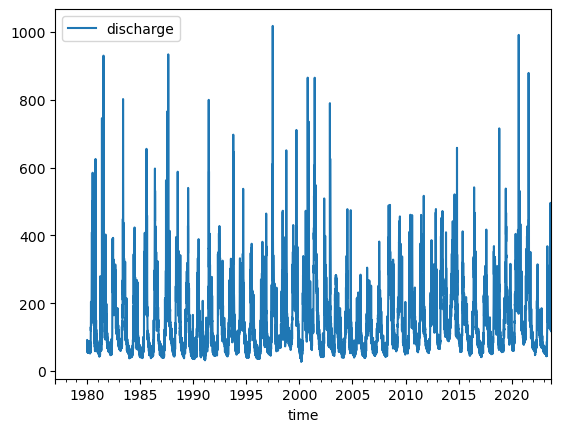

In [12]:
Q.plot(x="time")

In [13]:
forcings = xr.open_dataset(input_dir_path / fn_forcings , chunks= {"time":100})
params = xr.open_dataset(input_dir_path / fn_params ,  chunks= {"time":100}).sel(layer=1)
targets = xr.open_dataset(input_dir_path / "run_default" / fn_targets, chunks= {"time":100}).sel(layer=1).isel(lat=slice(None, None, -1))

In [14]:
try:
    forcings = forcings.rename({"latitude":"lat", "longitude":"lon"})
    params = params.rename({"latitude":"lat", "longitude":"lon"})
except:
    pass

In [15]:
wflow_lakes = params.wflow_lakeareas.values

In [16]:
wflow_dem = params.wflow_dem

In [17]:
#hand = xr.open_dataset(fp_surr_hand).rename({"band_data":"hand"})

In [18]:
try:
    distance = xr.open_dataset(fp_surr_distance).rename({"__xarray_dataarray_variable__":"distance"})
except:
    distance = xr.open_dataset(fp_surr_distance)

In [19]:
hao = xr.open_dataset(fp_surr_hao).rename({"band_data":"hao"})

In [20]:
params["distance"]= (("lat", "lon"), distance.distance.data)

In [21]:
#params["hand"]= (("lat", "lon"), hand.hand.data)

In [22]:
params["hao"]= (("lat", "lon"), hao.hao.data)

In [23]:
forcings = forcings[dynamic_names]
params = params[static_names]
targets = targets[target_names] 

In [24]:
#params["distance"] = (1/(params.distance + 1))

In [25]:
# select discharge 
discharge = pd.read_csv(fp_discharge_outlets).filter(regex=f"Q_{outlet_id}|time", axis=1)
discharge['time'] = pd.to_datetime(discharge.time)

In [26]:
# training 

spatial_batch_size = 256
temporal_sampling_size = 150
seq_length = 365 # days

# model 

hidden_size = 24

model_params={
    "input_size": 3, #number of dynamic predictors - user_input
    "hidden_size": hidden_size, # user_input
    "output_size": len(target_names), # number_target - user_input
    "number_static_predictors": len(static_names), #number of static parameters - user_input 

}

## The used device for training
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [27]:
remove_lakes = True

# if remove_lakes:
#     mask_lakes = (targets.mean(dim = "time")[target_names[0]] == 0).astype(np.bool_)
#     targets = targets.where(~mask_lakes, np.nan)
#     forcings = forcings.where(~mask_lakes, np.nan)
#     params = params.where(~mask_lakes, np.nan)

remove_lakes = True

if remove_lakes:
    mask_lakes = (wflow_lakes > 0).astype(np.bool_)

In [28]:
if train_timeslice:
    train_forcings = forcings.sel(time=train_timeslice)
    train_targets = targets.sel(time=train_timeslice)
    
    train_discharge  = discharge.loc[(discharge.time >= train_start_date) & (discharge.time <= train_end_date)]
    train_ado_discharge = Q.loc[(Q.time >= train_start_date) & (Q.time <= train_end_date)]

    valid_forcings = forcings.sel(time=valid_timeslice)
    valid_targets = targets.sel(time=valid_timeslice)
    
    valid_discharge  = discharge.loc[(discharge.time >= valid_start_date) & (discharge.time <= valid_end_date)]
    valid_ado_discharge = Q.loc[(Q.time >= valid_start_date) & (Q.time <= valid_end_date)]

<AxesSubplot: xlabel='time'>

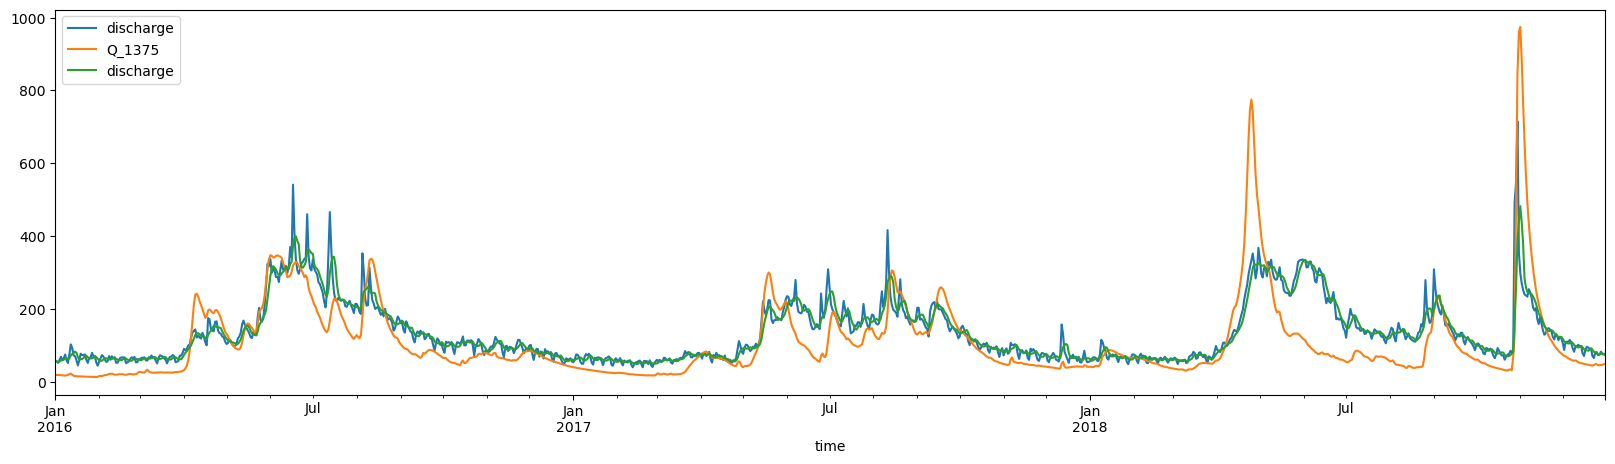

In [29]:
fig,ax = plt.subplots(1,1, figsize=(20,5))
train_ado_discharge.plot(x="time", ax=ax)
train_discharge.plot(x="time",ax=ax, label="wflow")
train_ado_discharge.set_index("time").rolling("5D").mean().plot(ax=ax, label="smooth")

<AxesSubplot: xlabel='time'>

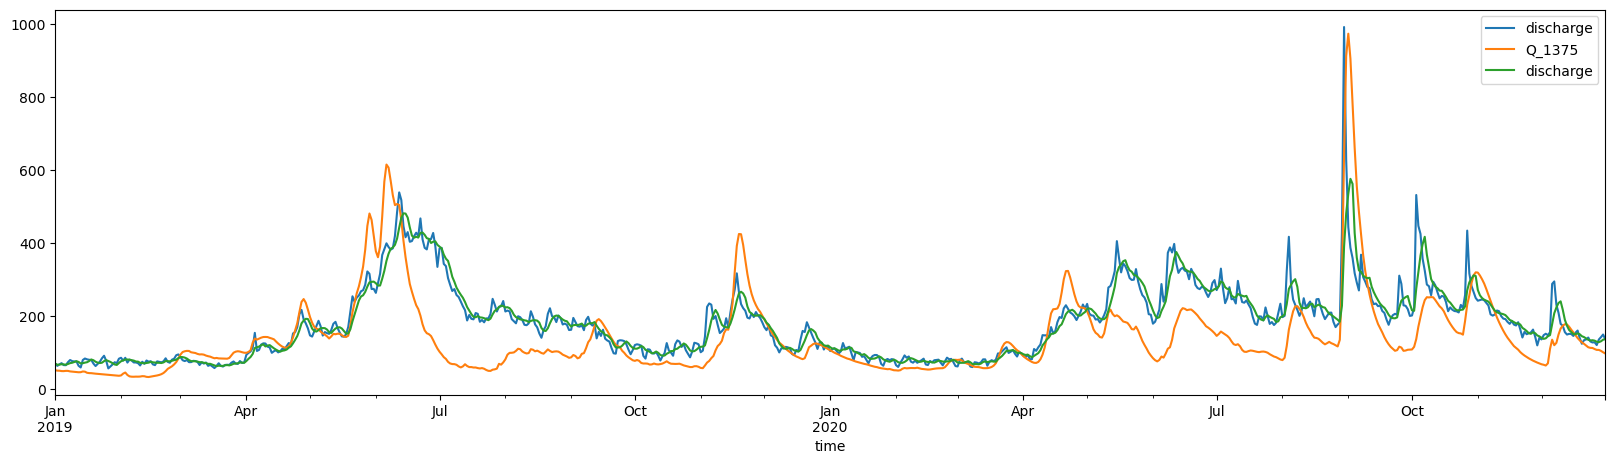

In [30]:
fig,ax = plt.subplots(1,1, figsize=(20,5))
valid_ado_discharge.plot(x="time", ax=ax)
valid_discharge.plot(x="time",ax=ax, label="wflow")
valid_ado_discharge.set_index("time").rolling("5D").mean().plot(ax=ax, label="smooth")

dynamic:  (18286, 1096, 3)  => (GRIDCELL, TIME, FEATURE)
static:  (18286, 5)  => (GRIDCELL, FEATURE)
target:  (18286, 1096, 3)  => (GRIDCELL, TIME, TARGET)
dynamic:  (18286, 731, 3)  => (GRIDCELL, TIME, FEATURE)
static:  (18286, 5)  => (GRIDCELL, FEATURE)
target:  (18286, 731, 3)  => (GRIDCELL, TIME, TARGET)


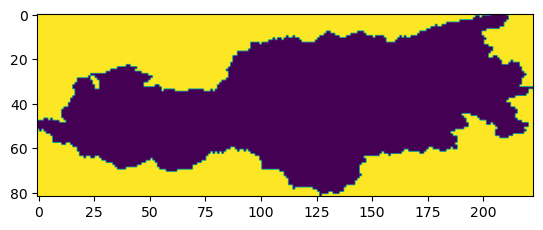

In [44]:
# UNCOMMENT IF NOT LOADING PREPROCESSED INPUTS

#reshape for training

Xd, Xs, Y  = reshape(
                   train_forcings, 
                   params, 
                   train_targets,
             return_type="numpy"
                   )

#Define the 2D missing values mask. Sampling 

if experiment == "smet_distr_and_dis_lumped":
    missing_mask = np.isnan(forcings["pet"].isel(time=0)).values | mask_lakes
elif experiment == "smet_distr_and_dis_distr":
    missing_mask = np.isnan(params["distance"]).values | np.isnan(params["hao"]).values | np.isnan(forcings["pet"].isel(time=0)).values | mask_lakes
else:
    missing_mask = np.isnan(params["distance"]).values | np.isnan(params["hao"]).values | np.isnan(forcings["pet"].isel(time=0)).values #| mask_lakes

plt.imshow(missing_mask)

# UNCOMMENT TO SAVE
# np.savez_compressed( surrogate_input_path / f"{wflow_model}", Xd=Xd, Xs=Xs, Y=Y, missing_mask = missing_mask)

Xd_valid, Xs_valid, Y_valid  = reshape(
                   valid_forcings, 
                   params, 
                   valid_targets,
    return_type="numpy"

)

In [45]:
no_sampling =False
if no_sampling:
    Xd = Xd[~missing_mask.flatten()]
    Xs = Xs[~missing_mask.flatten()]

In [46]:
#option SM + Q
if experiment == "smet_distr_and_dis_lumped":
    Y2 = train_discharge[f"Q_{outlet_id}"].values
    # Y = train_ado_discharge["discharge"].values
    # Y = train_ado_discharge.set_index("time").rolling("5D").mean().discharge.values
    
    #ymean = Y2.mean()
    #ystd = Y2.std()
    
    Y2 = np.expand_dims(Y2,(0,2))# batch, time, feat
    
    #Y = (Y - ymean)/ ystd
    
    Y_valid2 =  valid_discharge[f"Q_{outlet_id}"].values
    
    #Y_valid =  valid_ado_discharge.set_index("time").rolling("5D").mean().discharge.values
    
    #Y_valid = (Y_valid - ymean)/ ystd
    
    Y_valid2= np.expand_dims(Y_valid2,(0,2))# batch, time, feat
    
    Y2 = np.repeat(Y2,Y.shape[0],axis=0)
    
    Y_valid2 = np.repeat(Y_valid2,Y.shape[0],axis=0)
    Y2.shape,Y_valid2.shape
    
    Y[...,[0]] = Y2
    Y_valid[...,[0]] = Y_valid2
    Y.shape,Y_valid.shape, Y.dtype
# Y = np.concatenate([Y, Y2], -1)
# Y_valid = np.concatenate([Y_valid, Y_valid2], -1)

In [47]:
Y.shape

(18286, 1096, 3)

In [48]:
Y.shape

(18286, 1096, 3)

In [49]:
#Option only Q
# Y = train_discharge[f"Q_{outlet_id}"].values
# #Y = train_ado_discharge["discharge"].values
# #Y = train_ado_discharge.set_index("time").rolling("5D").mean().discharge.values

# ymean = Y.mean()
# ystd = Y.std()

# Y = np.expand_dims(Y,(0,2))# batch, time, feat

# Y = (Y - ymean)/ ystd

# Y_valid =  valid_discharge[f"Q_{outlet_id}"].values

# #Y_valid =  valid_ado_discharge.set_index("time").rolling("5D").mean().discharge.values

# Y_valid = (Y_valid - ymean)/ ystd

# Y_valid= np.expand_dims(Y_valid,(0,2))# batch, time, feat


# Y_valid.shape

In [50]:
intervals = (5, 5) # every n km
train_origin = (0, 0)
val_origin = (3, 3)

spatial_train_sampler = RegularIntervalSampler(intervals = intervals, origin = train_origin)
spatial_val_sampler = RegularIntervalSampler(intervals = intervals, origin = val_origin) 

In [51]:
data2d  = forcings.to_dataarray().transpose("lat","lon", "time", "variable")

sampler_train_meta = spatial_train_sampler.sampling_idx(data2d, missing_mask)
sampler_val_meta = spatial_val_sampler.sampling_idx(data2d, missing_mask)

In [52]:
sampler_val_meta.idx_sampled_1d[:10],sampler_train_meta.idx_sampled_1d[:10]

(array([672, 677, 682, 687, 692, 697, 702, 707, 712, 717]),
 array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45]))

In [53]:
# _, d_m, d_std = apply_normalization(Xd, type = "spacetime", how ='standard')
# _, s_m, s_std = apply_normalization(Xs, type = "space", how ='standard')

In [54]:
if no_sampling:
    
    _, d_m, d_std = apply_normalization(Xd[sampler_train_meta.idx_sampled_1d_nomissing], type = "spacetime", how ='standard')
    _, s_m, s_std = apply_normalization(Xs[sampler_train_meta.idx_sampled_1d_nomissing], type = "space", how ='standard')
else:
    _, d_m, d_std = apply_normalization(Xd[sampler_train_meta.idx_sampled_1d_nomissing], type = "spacetime", how ='standard')
    _, s_m, s_std = apply_normalization(Xs[sampler_train_meta.idx_sampled_1d_nomissing], type = "space", how ='standard')   

In [55]:
_, y_m, y_std = apply_normalization(Y[sampler_train_meta.idx_sampled_1d_nomissing], type = "spacetime", how ='standard')

In [56]:
Xd = apply_normalization(Xd, type="spacetime", how="standard", m1 = d_m, m2 = d_std).compute()
Xs = apply_normalization(Xs, type="space", how="standard",  m1 = s_m, m2 = s_std).compute()

In [57]:
Y = apply_normalization(Y, type="spacetime",how="standard", m1 = y_m, m2 = y_std).compute()

In [58]:
Xd_valid = apply_normalization(Xd_valid, type="spacetime", how="standard", m1 = d_m, m2 = d_std).compute()

In [59]:
Y_valid = apply_normalization(Y_valid, type="spacetime", how="standard", m1 = y_m, m2 = y_std).compute()

In [60]:
Xd_valid = torch.Tensor(Xd_valid)

In [61]:
Y_valid = torch.Tensor(Y_valid)

In [62]:
Y_valid.shape

torch.Size([18286, 731, 3])

In [63]:
Xs = torch.Tensor(Xs)
Xd = torch.Tensor(Xd)
Y = torch.Tensor(Y)

Xs.shape, Xd.shape, Y.shape

(torch.Size([18286, 5]),
 torch.Size([18286, 1096, 3]),
 torch.Size([18286, 1096, 3]))

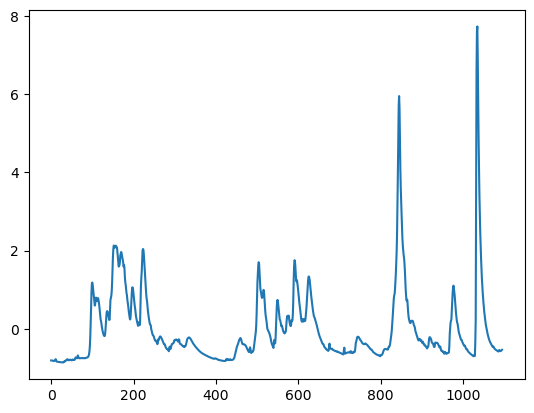

In [64]:
plt.plot(Y[13220,:,0].numpy())

In [65]:
#np.isnan(Xs[sampler_train_meta.idx_sampled_1d_nomissing]).any(), np.isnan(Xd[sampler_train_meta.idx_sampled_1d_nomissing]).any(),np.isnan(Y[sampler_train_meta.idx_sampled_1d_nomissing]).any()

In [66]:
# init datasets
dataset = LSTMDataset(Xd, Y, Xs) #LSTMDischargeDataset(Xd,Y,Xs) #  #LSTMDischargeDataset(Xd,Y,Xs) # LSTMDataset(Xd, Y, Xs) #


In [67]:
train_sampler = DataLoaderSpatialSampler(dataset, num_samples=100, sampling_indices = sampler_train_meta.idx_sampled_1d_nomissing.tolist())
valid_sampler = DataLoaderSpatialSampler(dataset, num_samples=100, sampling_indices = sampler_val_meta.idx_sampled_1d_nomissing.tolist())

In [68]:
train_loader = DataLoader(dataset, batch_size=spatial_batch_size, shuffle=False, sampler = train_sampler) # implement shuffling in the sampler!
val_loader = DataLoader(dataset, batch_size=spatial_batch_size, shuffle=False, sampler = valid_sampler)

In [69]:
model =  Surrogate(model_params, experiment)#
model = model.to(device)
model

Surrogate(
  (lstm_dis): DisLSTM(
    (fc0): Linear(in_features=8, out_features=32, bias=True)
    (lstm): LSTM(32, 32, batch_first=True)
    (fc1): Linear(in_features=32, out_features=1, bias=True)
  )
  (lstm_smet): CustomLSTM(
    (fc0): Linear(in_features=8, out_features=24, bias=True)
    (lstm): LSTM(24, 24, batch_first=True)
    (fc1): Linear(in_features=24, out_features=2, bias=True)
  )
)

In [70]:
experiment

'smet_distr_and_dis_lumped'

In [71]:
path2models= "./checkpoints" 
if not os.path.exists(path2models):
    os.mkdir(path2models)


opt = optim.Adam(model.parameters(), lr=1e-2)


loss_fn = RMSELoss()

metric_fn = mse_metric

lr_scheduler = ReduceLROnPlateau(opt, mode='min',factor=0.5, patience=10)

epochs = 60

params_train={
    "num_epochs": epochs,
    "temporal_sampling_idx_change_with_epoch": True,
    "temporal_sampling_size": temporal_sampling_size,
    "seq_length": seq_length,
    "ts_range": Y.shape[1],
    "optimizer": opt,
    "loss_func": loss_fn,
    "metric_func": metric_fn,
    "train_dl": train_loader, 
    "val_dl": val_loader,
    "lr_scheduler": lr_scheduler,
    "path2weights": f"{path2models}/weights.pt",
    "device":device,
    "target_names": target_names[1:],
    "experiment": experiment


}

In [73]:
model, sm_loss_history, sm_metric_history = train_val(model, params_train)

Epoch 0/59, current lr=0.01
discharge: tensor(2.8648, device='cuda:0', grad_fn=<DivBackward0>)
discharge: tensor(2.4872, device='cuda:0')
Copied best model weights!
train loss: tensor([0.5879], device='cuda:0', grad_fn=<DivBackward0>), train metric: [0]
val loss: tensor([0.5104], device='cuda:0'), val metric: [0]
----------
Epoch 1/59, current lr=0.01
discharge: tensor(2.4872, device='cuda:0', grad_fn=<DivBackward0>)
discharge: tensor(2.7651, device='cuda:0')
train loss: tensor([0.5104], device='cuda:0', grad_fn=<DivBackward0>), train metric: [0]
val loss: tensor([0.5674], device='cuda:0'), val metric: [0]
----------
Epoch 2/59, current lr=0.01
discharge: tensor(2.7651, device='cuda:0', grad_fn=<DivBackward0>)
discharge: tensor(2.4905, device='cuda:0')
train loss: tensor([0.5674], device='cuda:0', grad_fn=<DivBackward0>), train metric: [0]
val loss: tensor([0.5110], device='cuda:0'), val metric: [0]
----------
Epoch 3/59, current lr=0.01
discharge: tensor(2.4905, device='cuda:0', grad_

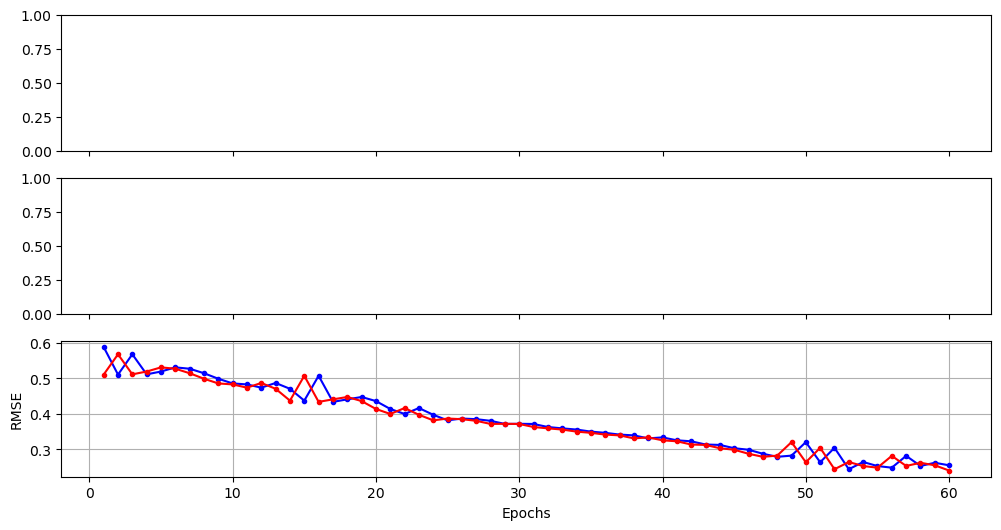

In [74]:
lepochs = list(range(1,params_train["num_epochs"] + 1))

fig, axs = plt.subplots(3, 1, figsize= (12,6), sharex=True)

# axs[0].plot(lepochs, sm_metric_history['train_vwc'], marker='.', linestyle='-', color='b', label='Training')
# axs[0].plot(lepochs, sm_metric_history['val_vwc'], marker='.', linestyle='-', color='r', label='Validation')
# #axs[0].title('Validation Loss - SM')
# axs[0].set_ylabel(metric_fn.__name__)
# axs[0].grid(True)
# axs[0].legend(bbox_to_anchor=(1,1))

# axs[1].plot(lepochs, sm_metric_history['train_actevap'], marker='.', linestyle='-', color='b', label='Training')
# axs[1].plot(lepochs, sm_metric_history['val_actevap'], marker='.', linestyle='-', color='r', label='Validation')
# #axs[0].title('Validation Loss - SM')
# axs[1].set_ylabel(metric_fn.__name__)
# axs[1].grid(True)

axs[2].plot(lepochs, [i.detach().cpu().numpy() for i in sm_loss_history['train']], marker='.', linestyle='-', color='b', label='Training')
axs[2].plot(lepochs, [i.detach().cpu().numpy() for i in sm_loss_history['val']], marker='.', linestyle='-', color='r', label='Validation')
#axs[0].title('Validation Loss - SM')
axs[2].set_xlabel('Epochs')
axs[2].set_ylabel(loss_fn.__name__)
axs[2].grid(True)

In [75]:
model.load_state_dict(torch.load(params_train["path2weights"]))

<All keys matched successfully>

In [76]:
from hython.utils import to_xr, predict_dis

In [77]:
# predict over the whole spatial domain using the model trained over the subsample
yhat = predict_dis(Xd.nanmean(0), Xs.nanmean(0), model, spatial_batch_size, device=device, model_name = "lstm_dis")
print(yhat.shape)

(1096, 1)


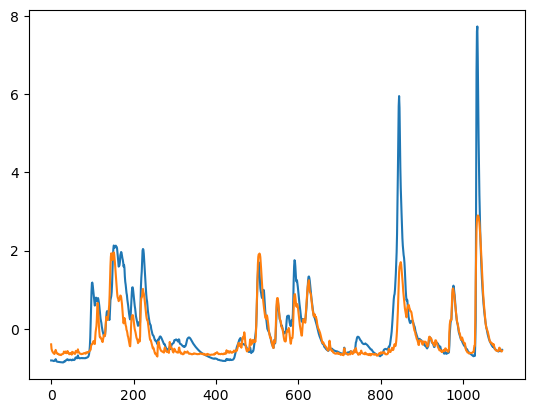

In [78]:
plt.plot(Y.numpy()[0,:,0])
plt.plot(yhat.squeeze())

In [79]:
# predict over the whole spatial domain using the model trained over the subsample
yhat_valid = predict_dis(Xd_valid.nanmean(0), Xs.nanmean(0), model, spatial_batch_size, device=device, model_name = "lstm_dis")
print(yhat_valid.shape)

(731, 1)


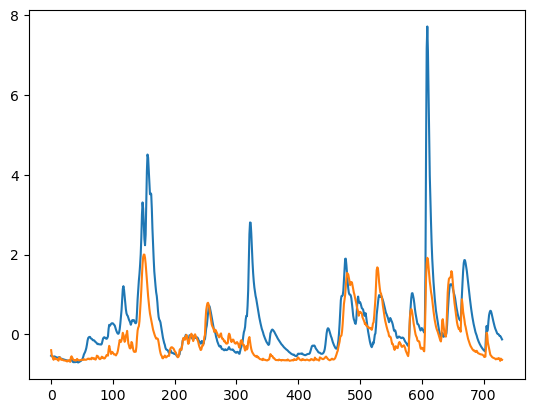

In [80]:
plt.plot(Y_valid.numpy()[0,:,0])
plt.plot(yhat_valid.squeeze())

In [ ]:
lat, lon, time = *train_forcings.to_dataarray().transpose("lat","lon", "time", "variable").shape[:2], Xd.shape[1]
lat*lon ,time

(18286, 1096)

In [129]:
yhat = predict(Xd, Xs, model, spatial_batch_size, device=device)

In [130]:
yhat.reshape(lat,lon,time,2).shape

(82, 223, 1096, 2)

In [117]:
# predict over the whole spatial domain using the model trained over the subsample
yhat_valid = predict(Xd_valid, Xs, model, spatial_batch_size, device=device)

lat, lon, time = *valid_forcings.to_dataarray().transpose("lat","lon", "time", "variable").shape[:2], Xd_valid.shape[1]
lat*lon ,time

(18286, 731)

In [118]:
ret_valid = to_xr(yhat_valid.reshape(lat,lon,time,2)[...,1], coords=valid_targets.coords)

In [119]:
target_valid = Y_valid.numpy()[...,[1,2]].reshape(lat,lon,time,2)[...,1]

In [134]:
target_valid = to_xr(target_valid,  coords=valid_targets.coords)

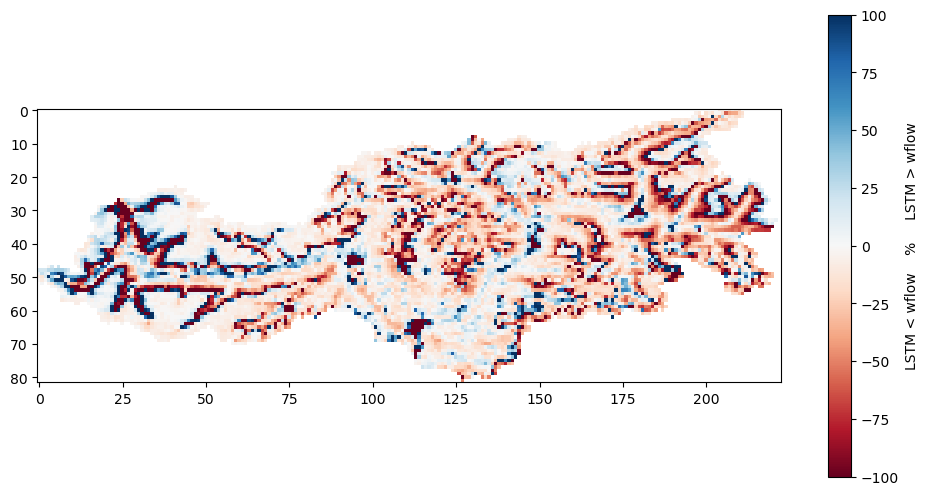

In [136]:
map_pbias(target_valid,ret_valid, figsize = (12, 12), kwargs_imshow={"vmin":-100, "vmax":100})

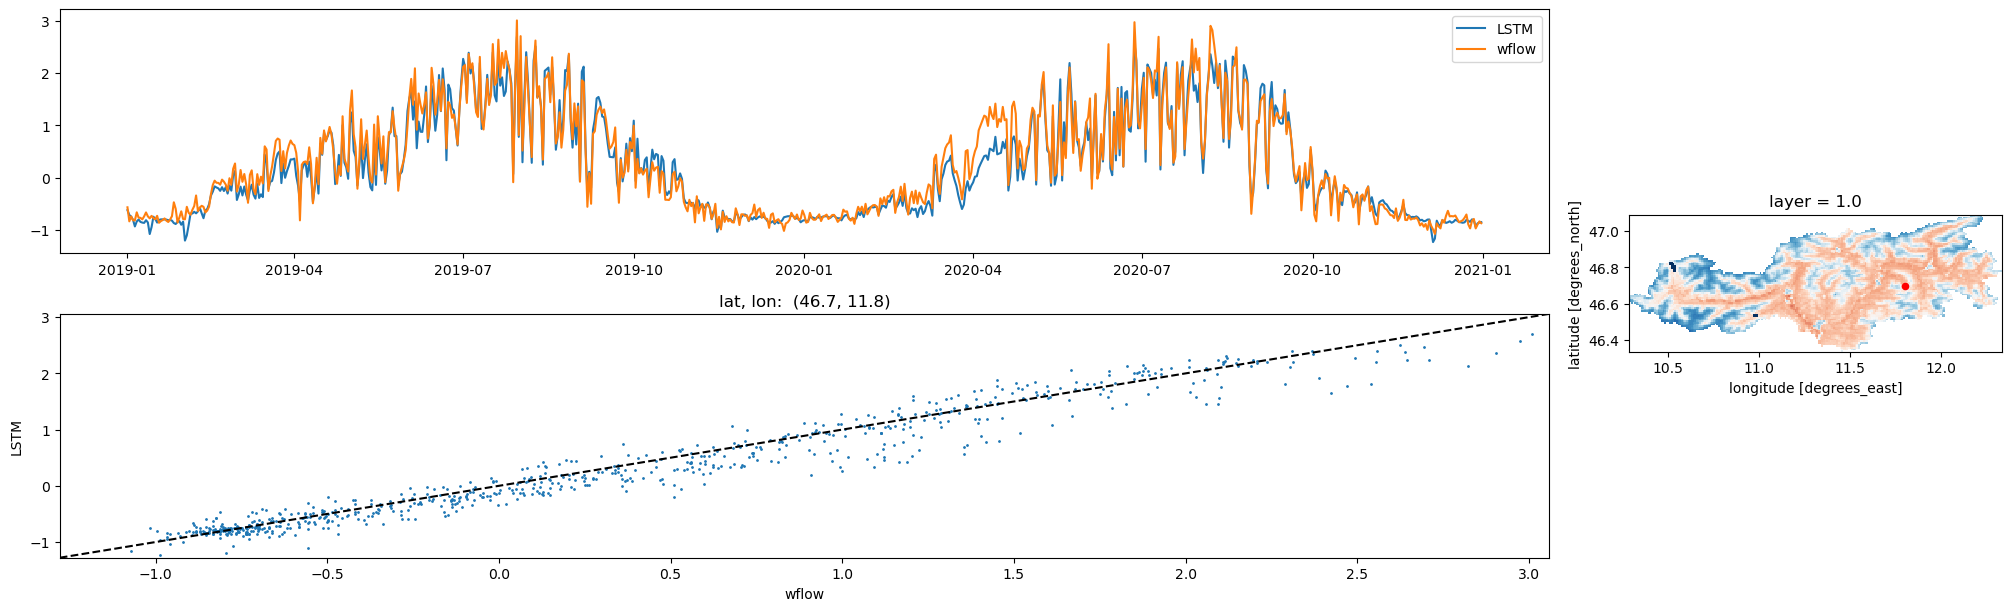

In [137]:
ts_compare(target_valid ,ret_valid, lat = [46.7], lon = [11.8])

In [129]:
map_at_timesteps(target_valid ,ret_valid,dates=["2019-01-01","2019-04-01", "2019-07-01", "2019-10-01"])

NameError: name 'target_valid' is not defined

In [211]:
# predict over the whole spatial domain using the model trained over the subsample
yhat_valid = predict_dis(Xd_valid.nanmean(0), Xs.nanmean(0), model, spatial_batch_size, device=device, model_name="lstm_dis")
print(yhat_valid[:10])
lat, lon, time = *valid_forcings.to_dataarray().transpose("lat","lon", "time", "variable").shape[:2], Xd_valid.shape[1]
lat*lon ,time

[[-0.40452713]
 [-0.5430198 ]
 [-0.5682122 ]
 [-0.61230505]
 [-0.70070434]
 [-0.59405226]
 [-0.58733904]
 [-0.613206  ]
 [-0.6010587 ]
 [-0.61271507]]


(18286, 731)

In [212]:
#ret_valid = to_xr(yhat_valid, coords=valid_targets.coords)

valid_precip = valid_forcings.precip.mean(["lat","lon"]).compute()
train_precip = train_forcings.precip.mean(["lat","lon"]).compute()

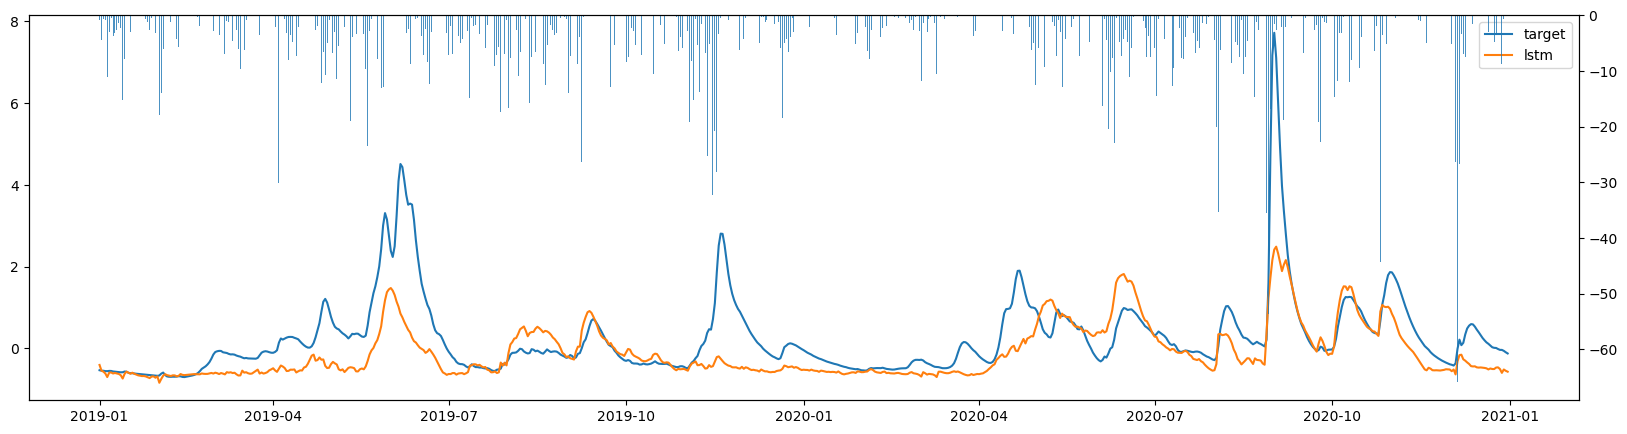

In [213]:
y_valid_plot = (Y_valid.numpy()[0,:,0])#*ystd +ymean
yhat_valid_plot = yhat_valid #ret_valid.sel(lat = outlet_lat_lon[0], lon = outlet_lat_lon[1], method="nearest").values#*ystd +ymean

fig, ax = plt.subplots(1,1, figsize=(20,5))
valid_time = pd.date_range(valid_start_date,valid_end_date, freq="1D")
ax2 = ax.twinx()
ax2.bar(valid_time,-valid_precip, 0.5, alpha=0.8, fill="black")
ax.plot(valid_time,y_valid_plot, label="target")
ax.plot(valid_time,yhat_valid_plot, label="lstm")
ax.legend()

In [214]:
Xd.shape

torch.Size([18286, 1096, 3])

In [215]:
yhat= predict_dis(Xd.nanmean(0), Xs.nanmean(0), model, spatial_batch_size, device=device, model_name="lstm_dis")

lat, lon, time = *train_forcings.to_dataarray().transpose("lat","lon", "time", "variable").shape[:2], Xd.shape[1]
lat*lon ,time


#ret = to_xr(yhat.reshape(lat,lon,time), coords=train_targets.coords)

(18286, 1096)

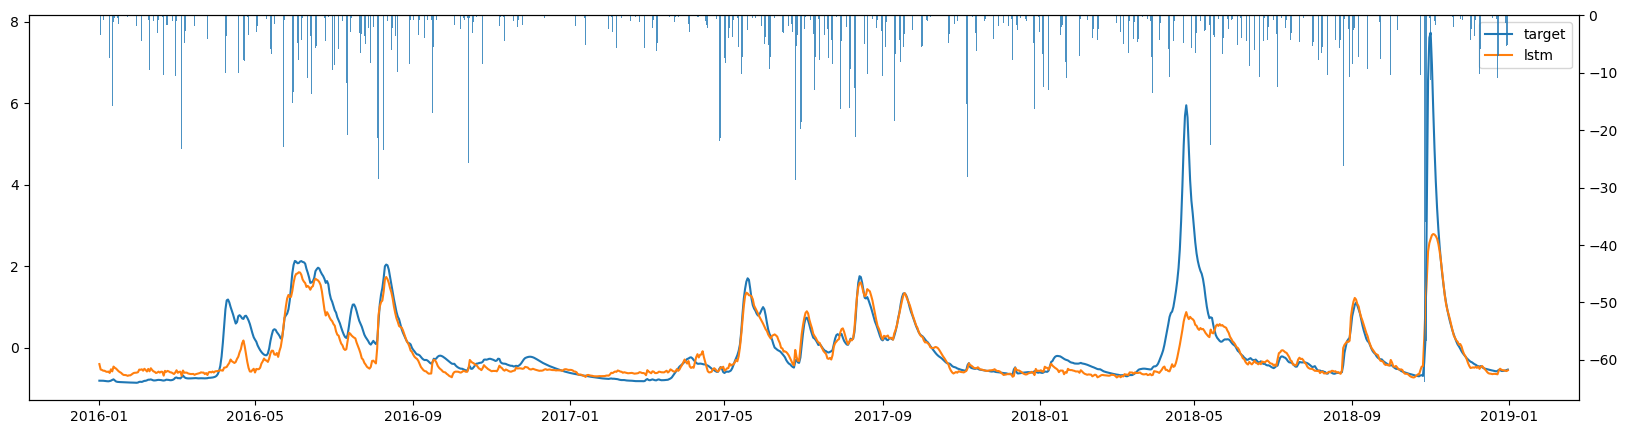

In [216]:
y_plot = (Y.numpy()[0,:,0])#*ystd +ymean
yhat_plot = yhat # ret.sel(lat = outlet_lat_lon[0], lon = outlet_lat_lon[1], method="nearest").values #*ystd +ymean

fig, ax = plt.subplots(1,1, figsize=(20,5))
train_time = pd.date_range(train_start_date,train_end_date, freq="1D")
ax2 = ax.twinx()
ax2.bar(train_time,-train_precip, 0.5, alpha=0.8, fill="black")
ax.plot(train_time,y_plot, label="target")
ax.plot(train_time,yhat_plot, label="lstm")
ax.legend()

In [151]:
# COMBINED

torch.cuda.empty_cache()

# predict over the whole spatial domain using the model trained over the subsample
yhat = predict(Xd, Xs, model, spatial_batch_size, device=device)
print(yhat.shape)

lat, lon, time = len(forcings.lat),len(forcings.lon), Xd.shape[1]
lat*lon ,time

yhat = (yhat*y_std) + y_m

# reshape data for plotting
y_target, y_pred = prepare_for_plotting(y_target=Y[:,:,[1]], y_pred = yhat[:,:,[0]], shape = (lat, lon, time), coords = train_targets.coords)
y_target.shape

y_target = (y_target*y_std[0]) + y_m[0]

y_target = y_target.chunk({"lat":20, "lon":20, "time":-1})


(18286, 1096, 2)


ValueError: operands could not be broadcast together with shapes (18286, 1096, 2) (3,)

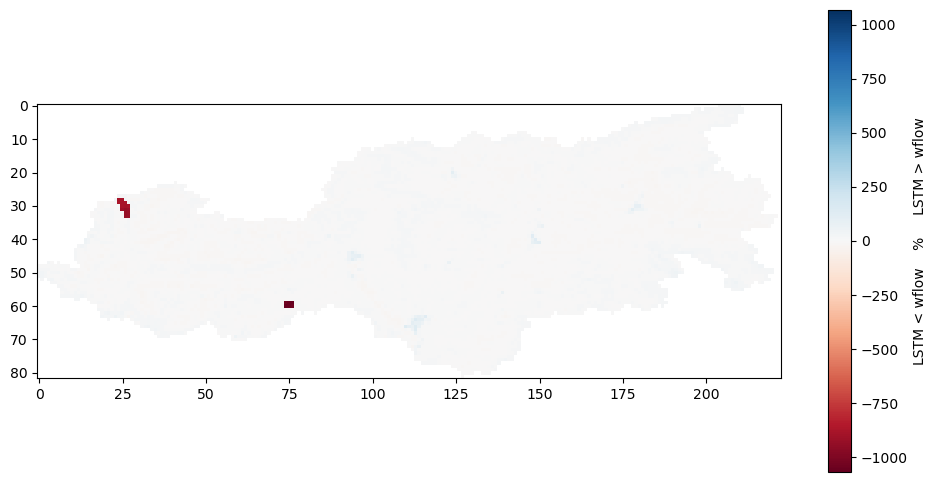

In [145]:
map_pbias(y_target, y_pred, figsize = (12, 12))

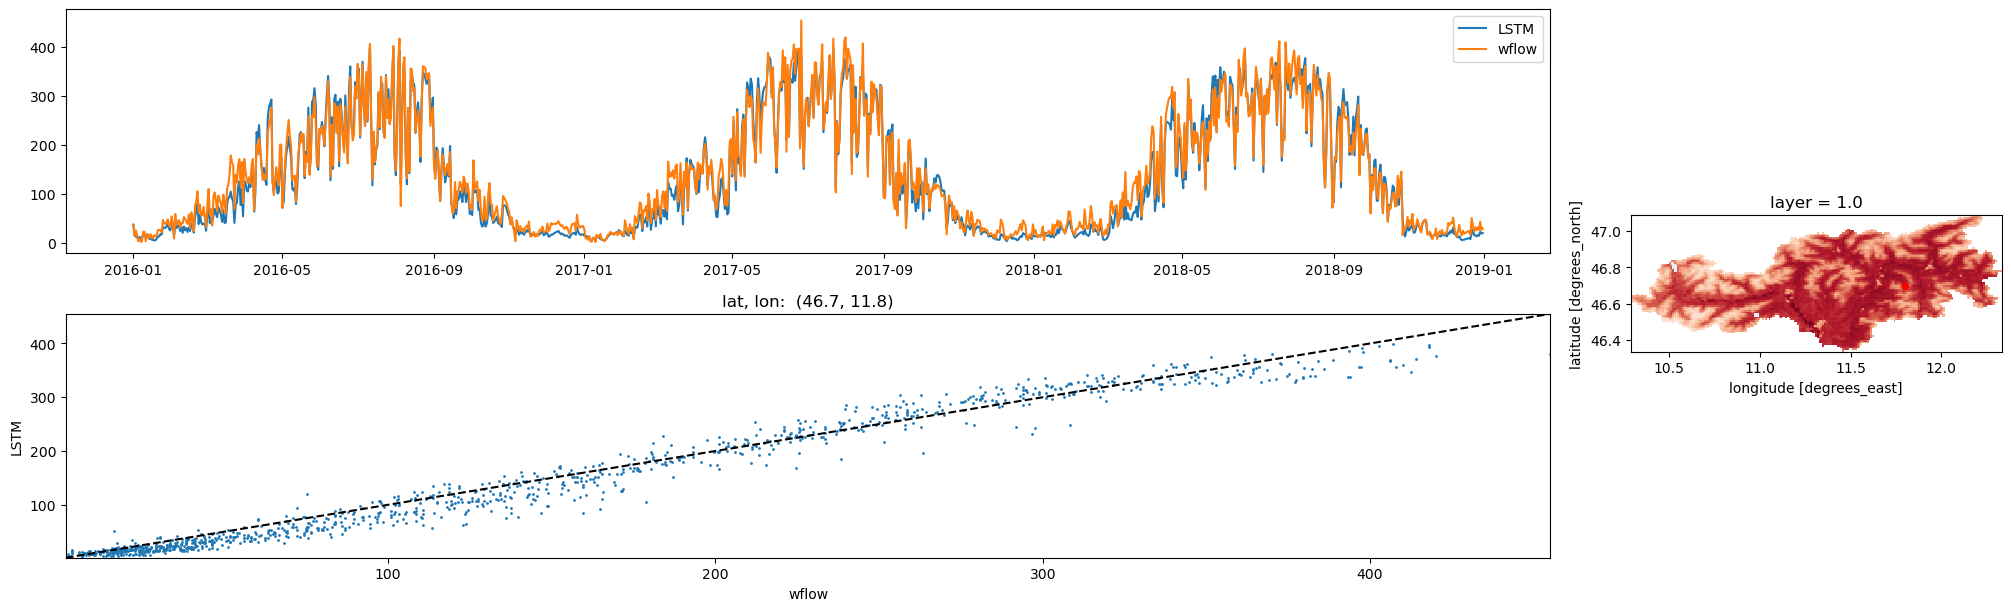

In [142]:
ts_compare(y_target, y_pred, lat = [46.7], lon = [11.8])

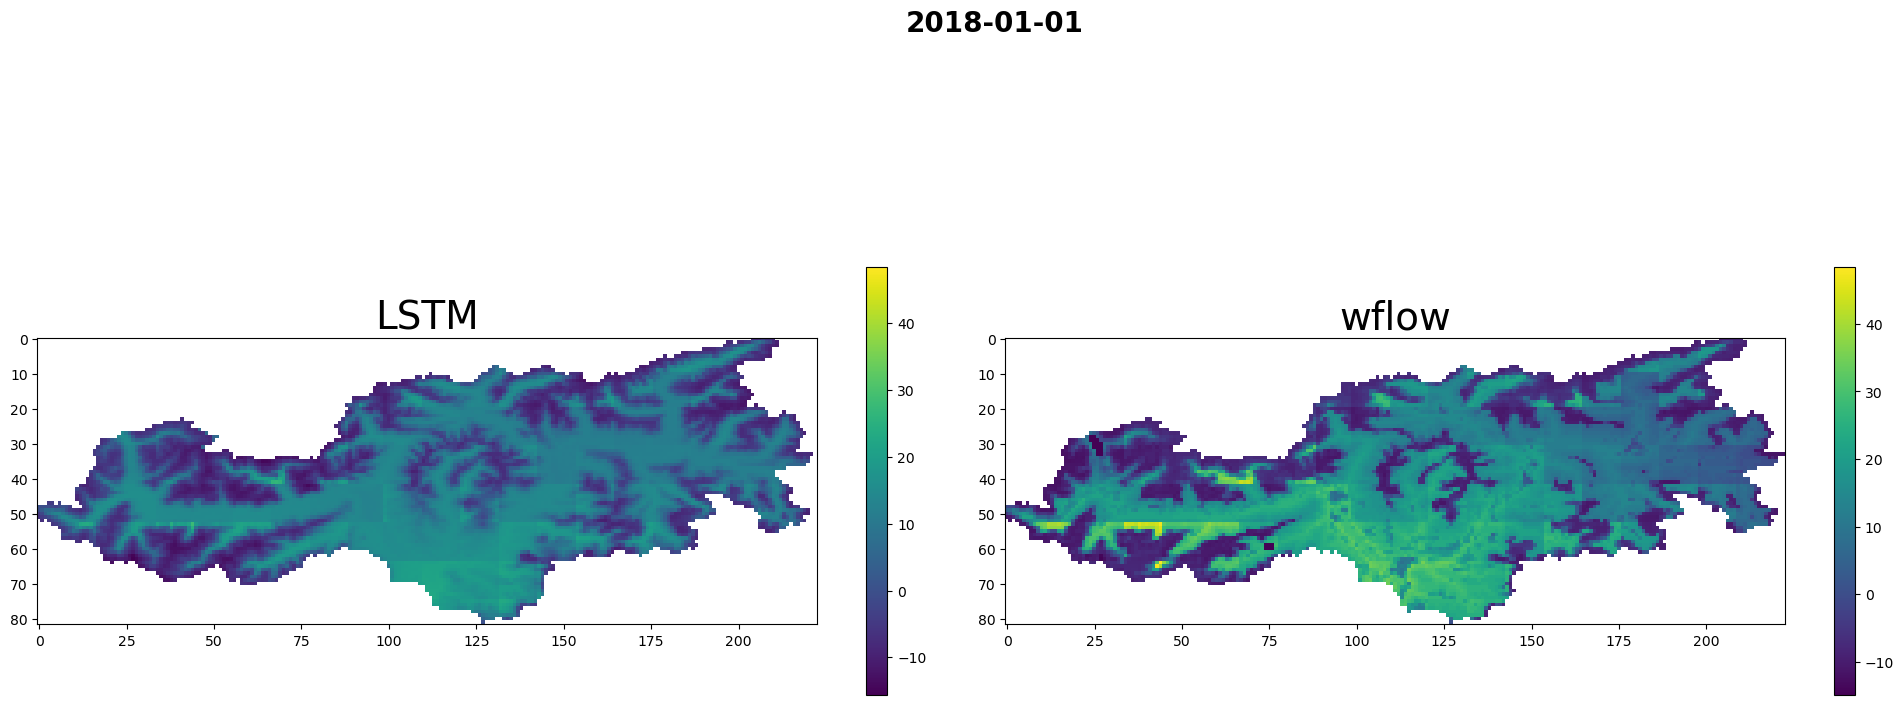

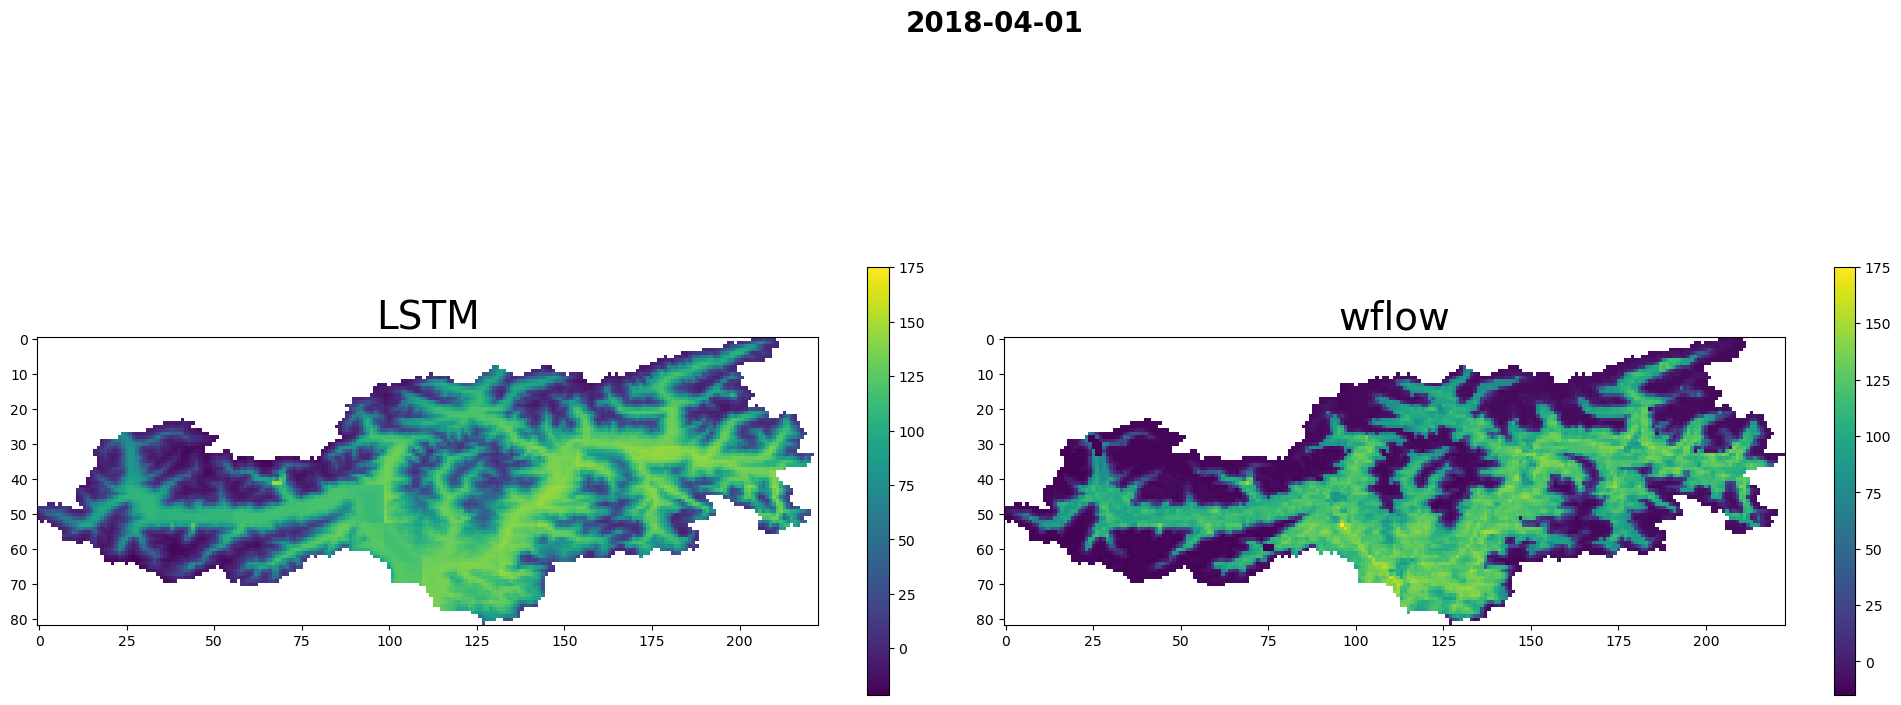

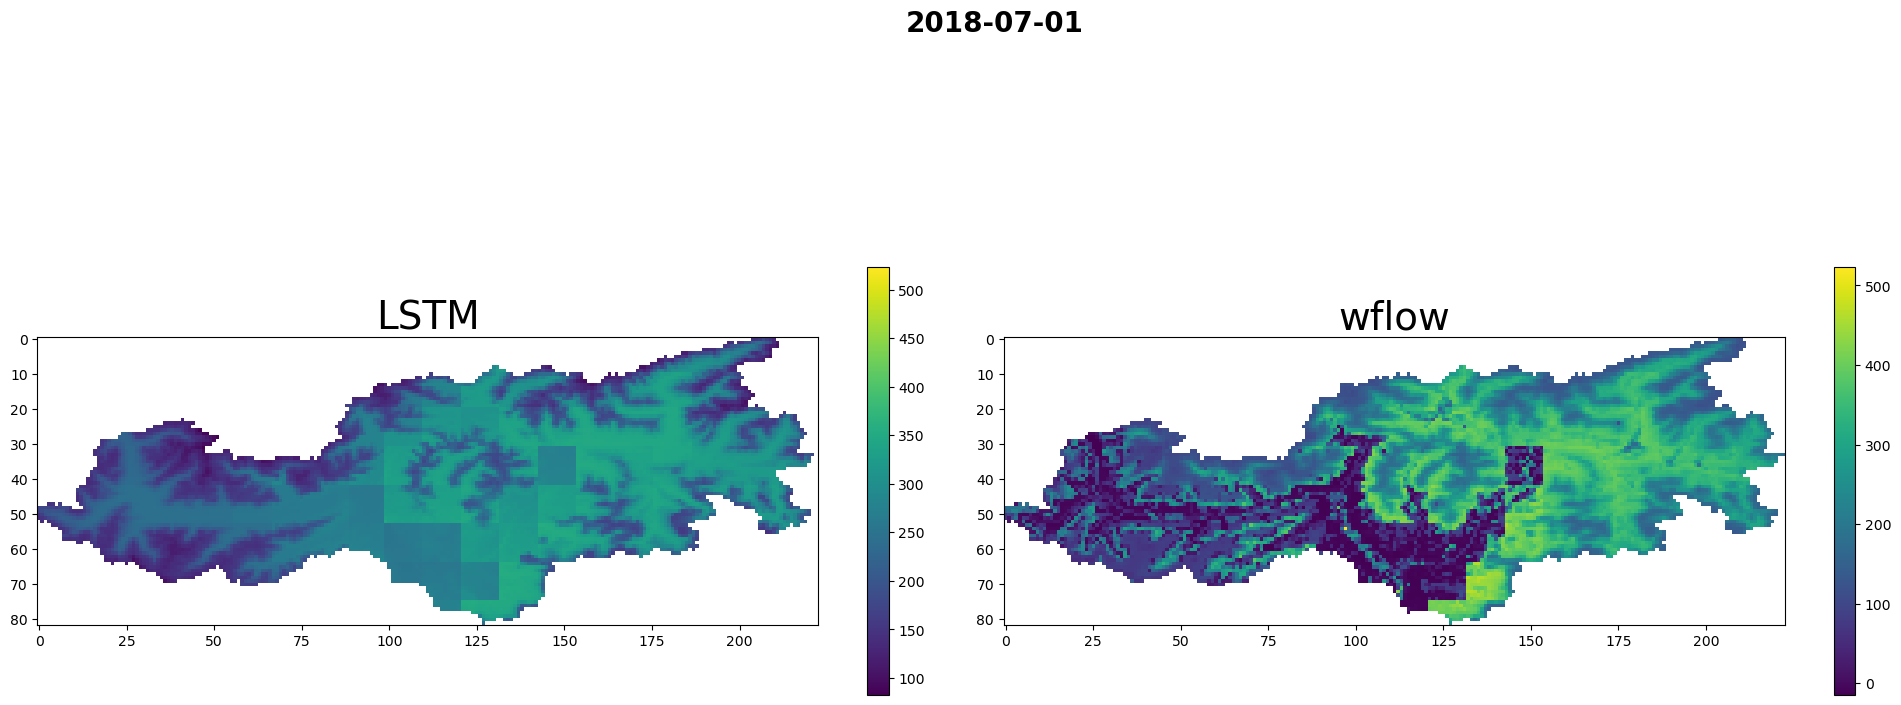

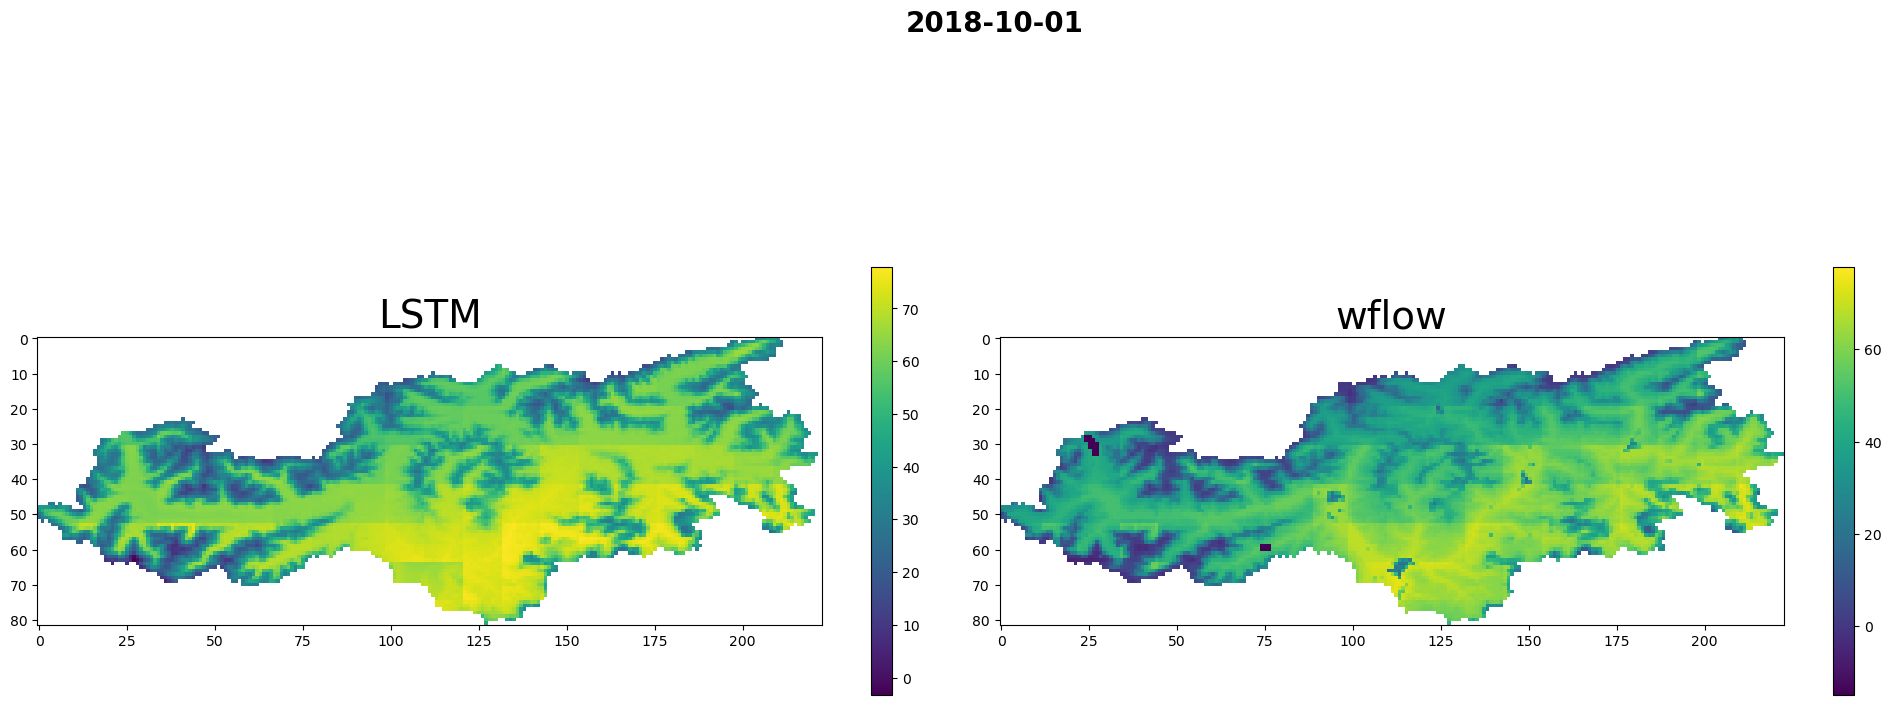

In [146]:
map_at_timesteps(y_target, y_pred,dates=["2018-01-01","2018-04-01", "2018-07-01", "2018-10-01"])

In [ ]:
# predict over the whole spatial domain using the model trained over the subsample
yhat = predict(Xd_valid, Xs, model, spatial_batch_size, device=device)
print(yhat.shape)

lat, lon, time = len(forcings.lat),len(forcings.lon), Xd_valid.shape[1]
lat*lon ,time

yhat = (yhat*y_std) + y_m

# reshape data for plotting
y_target, y_pred = prepare_for_plotting(y_target=Y_valid[:,:,[0]], y_pred = yhat[:,:,[0]], shape = (lat, lon, time), coords = valid_targets.coords)
y_target.shape

y_target = (y_target*y_std[0]) + y_m[0]

y_target = y_target.chunk({"lat":20, "lon":20, "time":-1})

In [ ]:
map_pbias(y_target, y_pred, figsize = (12, 12))

In [ ]:
ts_compare(y_target, y_pred, lat = [46.7], lon = [11.8])

In [ ]:
map_at_timesteps(y_target, y_pred,dates=["2019-01-01","2019-04-01", "2019-07-01", "2019-10-01"])

In [ ]:
yhat.reshape(lat,lon,time,2)

In [ ]:
ret_valid = to_xr(yhat.reshape(lat,lon,time,2).compute()[...,1], coords=valid_targets.coords)

In [ ]:
outlet_lat_lon

In [ ]:
valid_precip = valid_forcings.precip.mean(["lat","lon"]).compute()

In [ ]:
Y_valid.numpy()[0,:,1].shape

In [ ]:
y_valid_plot = (Y_valid.numpy()[0,:,1])*y_std[1] +y_m[1]
yhat_valid_plot = ret_valid.sel(lat = outlet_lat_lon[0], lon = outlet_lat_lon[1], method="nearest").values

fig, ax = plt.subplots(1,1, figsize=(20,5))
valid_time = pd.date_range(valid_start_date,valid_end_date, freq="1D")
ax2 = ax.twinx()
ax2.bar(valid_time,-valid_precip, 0.5, alpha=0.8, fill="black")
ax.plot(valid_time,y_valid_plot, label="target")
ax.plot(valid_time,yhat_valid_plot, label="lstm")
ax.legend()


ET + SM + Q: All distributed!  

## ET + SM + Q: One lumped, the other distributed

In [ ]:
# input



In [ ]:
class SMEP(nn.Module):
   ...:     def __init__(self):
   ...:         super(SMEP, self).__init__()
   ...:         self.distr = nn.Linear(8,2, bias=False)
    
   ...:         self.linear = nn.Linear(2,1, bias=False)
    
   ...:     def forward(self, X):
   ...:         sm_evap = torch.stack([self.distr(time) for time in X ])#;print(sm_evap.shape)
   ...:         #q1 = torch.mean(sm_evap,0)#;print(q1.shape) n batches -> (20,2)
   ...:         #q = self.linear(q1)#;print(q.shape) smet -> (20,1)
   ...:         return sm_evap

In [ ]:
class Dis(nn.Module):
    def __init__(self):
        super(Dis, self).__init__()
        self.linear = nn.Linear(2,1, bias=False)
    def forward(self, smet):
        q1 = torch.mean(smet, 0)
        #;print(q1.shape)  #n batches -> (20,2)
        q = self.linear(q1)
        #;print(q.shape) #smet -> (20,1)    
        return q
        

In [ ]:
model1 = SMEP()
model2 = Dis()

In [ ]:
#q, smet = model(P)

In [ ]:
# # Create DataLoader
#train_dataset = TensorDataset(P, Y)

#train_loader = DataLoader(train_dataset, batch_size=3, shuffle=True)

In [ ]:
import itertools

criterion = nn.MSELoss()
optimizer = optim.Adam(itertools.chain(model1.parameters(), model2.parameters()), lr=0.001)

# Training loop
num_epochs = 1000

qq = []
smsm = []

for epoch in range(num_epochs):
    model1.train()
    model2.train()
    smet_all = []
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        # Forward pass
        smet = model1(batch_X)
        smet_all.append(smet)
        #print(batch_y[...,[2]].shape,batch_y[...,[0,1]].shape)
        
        #loss_q = criterion(q, batch_y[[2]])
        #loss_smet = criterion(smet, batch_y[...,[0,1]])

        #loss = loss_q + loss_smet
        # Backward pass
        #loss.backward()

        # Update weights
        #optimizer.step()
    smetall = torch.cat(smet_all)

    q = model2(smetall)
    #print(q)
    #print(train_loader.dataset.tensors[1][...,[2]].shape)
    
    loss_q = criterion(q,train_loader.dataset.y[1][...,[2]])
    loss_smet = criterion(smetall, train_loader.dataset.y[1][...,[0,1]] )

    loss = loss_q + loss_smet

    loss.backward()

    optimizer.step()
    
    #print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}')

In [ ]:
def predict(model1, model2, input_data, batch_size=3):
    model1.eval()
    model2.eval()
    
    # with torch.no_grad():
    #     input_tensor = torch.tensor(input_data, dtype=torch.float32)
    #     # Ensure the input tensor has the correct shape (batch_size, input_channels, height, width)
    #     # if len(input_tensor.shape) == 3:
    #     #     input_tensor = input_tensor.unsqueeze(0)
        
    #     smet = model(input_tensor)
    with torch.no_grad():

        SMET = []
        for i in range(0,input_data.shape[0], batch_size):
            
            smet = torch.Tensor(input_data[i:(i+batch_size)])
            
            SMET.append(
                model1(smet)
                )
        smetall = torch.cat(SMET)

        q = model2(smetall)

    return q.numpy(), smetall.numpy()

In [ ]:
pq, psmet = predict(model1, model2, P)

In [ ]:
plt.plot(pq)
plt.plot(Q[0], label = "true")
plt.legend()

In [ ]:
plt.plot(Y[...,[1,2]].numpy()[10], label="orig")
plt.plot(psmet[10])
plt.legend()